In [18]:
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [4]:
df = pd.read_csv('fraud.csv')

In [5]:
print(df)

   Amount  Time  Fraud
0     100     2      0
1     200     3      0
2    5000     1      1
3     150     5      0
4    7000     2      1
5     300     6      0
6    9000     1      1
7     400     7      0


In [10]:
x = df[['Amount', 'Time']]
y = df['Fraud']

In [11]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation='relu', input_shape=(2,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
def f(x): max(0,x)

In [13]:
def f(x): return 1/(1+tf.exp(-x))

In [14]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [16]:
history = model.fit(x,y, epochs=300)

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3750 - loss: 51.3847
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.3750 - loss: 51.0664
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.3750 - loss: 50.7482
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.3750 - loss: 50.4299
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.3750 - loss: 50.1116
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.3750 - loss: 49.7934
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3750 - loss: 49.4751
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.3750 - loss: 49.1569
Epoch 9/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.3750 - loss: 48.8386
Epoch 10/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.3750 - loss: 48.5203
Epoch 11/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.3750 - loss: 48.2020
Epoch 12/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.

In [31]:
prediction = model.predict(np.array([[10000,6]]))
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
[[0.9970517]]


In [32]:
if prediction > 0.5:
  print("Fraud Detected")
else:
  print("Normal Transaction")

Fraud Detected


In [34]:
prediction = model.predict(np.array([[10,6]]))
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
[[0.30309224]]


In [35]:
if prediction > 0.5:
  print("Fraud Detected")
else:
  print("Normal Transaction")

Normal Transaction


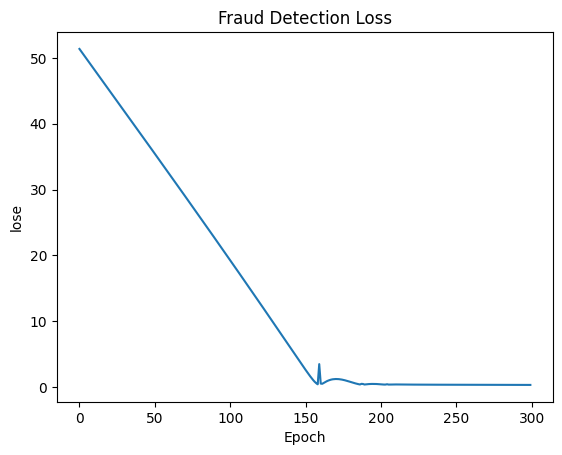

In [36]:
plt.plot(history.history['loss'])
plt.xlabel('Epoch')
plt.ylabel('lose')
plt.title('Fraud Detection Loss')
plt.show()